# MOwNiT
## Laboratorium 1
### Analiza danych - DataFrames

- Zaawansowany pakiet do działania na tabelkach nxm danych 
- Podobne do pandas DataFrames w Pythonie albo data.frame w R
- Specjalistyczne funkcje do statystyki
- W przypadku włąsnej instalacji należy zaistalować pakiet:

```julia
Pkg.add("DataFrames" )
```

- DataFrame to rodzaj bazy danych in-memory
- Składa się z kolumn, do których odwołujemy się używając symboli
- Każda z kolumn może przechowywać inny typ (inaczej niż w dwuwymiarowych tablicach )
- każda z kolumn jest typu Array{T,1} gdzie T jest okreslonym typem danych (np. Float64)
- strona pakietu: https://github.com/JuliaStats/DataFrames.jl
- dokumentacja najnowszej wersji: https://juliadata.github.io/DataFrames.jl/stable/index.html





In [1]:
# za pierwszym razem, jeśli uruchamiamy lokalnie to instalujemy
# using Pkg
# Pkg.add("DataFrames")
import Pkg
Pkg.add("Plots")
Pkg.add("CSV")
Pkg.add("DataFrames")
Pkg.add("Statistics")
Pkg.add("LinearAlgebra")
Pkg.add("BenchmarkTools")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.

In [2]:
# Tworzenie DataFrame
using DataFrames
df1=DataFrame()
df1.MojaKolumna= 1:4
df1.x2= [4,pi,sqrt(2), 42]
df1.Col3= [true,false, true, false]
show(df1)

4×3 DataFrame
 Row │ MojaKolumna  x2        Col3  
     │ Int64        Float64   Bool  
─────┼──────────────────────────────
   1 │           1   4.0       true
   2 │           2   3.14159  false
   3 │           3   1.41421   true
   4 │           4  42.0      false

In [3]:
# ! - nie tworzy kopii, : - tworzy kopię
typeof(df1[!,2])

Vector{Float64} (alias for Array{Float64, 1})

In [4]:
typeof(df1[:,2])

Vector{Float64} (alias for Array{Float64, 1})

In [5]:
typeof(df1.Col3)

Vector{Bool} (alias for Array{Bool, 1})

In [6]:
# możemy też utworzyć DataFrame używając konstruktora
df2=DataFrame(MojaKolumna=1:10, 
    Col2=[2,pi, sqrt(2), 3, 4,2,pi, sqrt(2), 3, 4], 
    Col3=[true,true,false,true,false,true,true,false,true,false])

Row,MojaKolumna,Col2,Col3
,Int64,Float64,Bool
1,1,2.0,true
2,2,3.14159,true
3,3,1.41421,false
4,4,3.0,true
5,5,4.0,false
6,6,2.0,true
7,7,3.14159,true
8,8,1.41421,false
9,9,3.0,true


In [7]:
# ilosc wierszy
size(df2, 1) 

10

In [8]:
#ilosc kolumn
size(df2, 2) 

3

In [9]:
# można odwoływać się po indeksie
show(df2[:,2])

[2.0, 3.141592653589793, 1.4142135623730951, 3.0, 4.0, 2.0, 3.141592653589793, 1.4142135623730951, 3.0, 4.0]

In [10]:
# albo po symbolu kolumny
show(df2[!,:Col2])

[2.0, 3.141592653589793, 1.4142135623730951, 3.0, 4.0, 2.0, 3.141592653589793, 1.4142135623730951, 3.0, 4.0]

In [11]:
# wiersze lub podzbiory wierszy i kolumn uzyskujemy poprzez operator (:). Wynikiem jest nowy DataFrame
show(df2[3,:])

DataFrameRow
 Row │ MojaKolumna  Col2     Col3  
     │ Int64        Float64  Bool  
─────┼─────────────────────────────
   3 │           3  1.41421  false

In [12]:
# drugi i trzeci wiersz
df2[2:3, :]

Row,MojaKolumna,Col2,Col3
,Int64,Float64,Bool
1,2,3.14159,true
2,3,1.41421,false


In [13]:
# druga kolumna drugiego i trzeciego wiersza
df2[2:3, :Col2]

2-element Vector{Float64}:
 3.141592653589793
 1.4142135623730951

In [14]:
# druga i trzecia kolumna drugiego i trzeciego wiersza
df2[2:3,[:Col2, :Col3]]

Row,Col2,Col3
,Float64,Bool
1,3.14159,true
2,1.41421,false


In [15]:
# pierwsze sześć wierszy
DataFrames.first(df2,6)

Row,MojaKolumna,Col2,Col3
,Int64,Float64,Bool
1,1,2.0,true
2,2,3.14159,true
3,3,1.41421,false
4,4,3.0,true
5,5,4.0,false
6,6,2.0,true


In [16]:
# ostatnie sześć wierszy
DataFrames.last(df2,6)

Row,MojaKolumna,Col2,Col3
,Int64,Float64,Bool
1,5,4.0,false
2,6,2.0,true
3,7,3.14159,true
4,8,1.41421,false
5,9,3.0,true
6,10,4.0,false


In [17]:
# nazwy kolumn
names(df2)

3-element Vector{String}:
 "MojaKolumna"
 "Col2"
 "Col3"

In [18]:
# typy kolumn
eltype.(eachcol(df2))

3-element Vector{DataType}:
 Int64
 Float64
 Bool

In [19]:
# podstawowe dane statystyczne o wartościach w kolumnie
describe(df2)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,MojaKolumna,5.5,1,5.5,10,0,Int64
2,Col2,2.71116,1.41421,3.0,4.0,0,Float64
3,Col3,0.6,false,1.0,true,0,Bool


In [20]:
using Statistics
mean(df2.Col2)

2.711161243192578

In [21]:
var(df2.Col2)

0.9150284373648316

In [22]:
#using Pkg
#Pkg.add("CSV")
using CSV
input="winequality.csv"
mydata=CSV.read(input, delim=";",DataFrame)

LoadError: ArgumentError: "winequality.csv" is not a valid file or doesn't exist

In [23]:
describe(mydata)

LoadError: UndefVarError: `mydata` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [24]:
typeof(mydata)

LoadError: UndefVarError: `mydata` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [25]:
size(mydata)

LoadError: UndefVarError: `mydata` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [26]:
# Dzielenie DataFrame na podgrupy i działania na nich

# Split -Apply - Combine

#https://dataframes.juliadata.org/stable/man/split_apply_combine/

# rozdzielanie na podgrupy po jakości wina (quality)
# Split

wine_grouped=groupby(mydata, :quality)

LoadError: UndefVarError: `mydata` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [27]:

# podsumowanie ile jest win w każdej grupie 
combine(wine_grouped, nrow)

LoadError: UndefVarError: `wine_grouped` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [28]:
combine(wine_grouped, "fixed acidity" => mean)

LoadError: UndefVarError: `wine_grouped` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [29]:
# zliczenie liczby win o danej jakości i zawartości alkoholu, posortowane
wine_grouped2=sort(combine(groupby(mydata, [:quality,:alcohol]),nrow=> :liczba), [:quality,:alcohol])

LoadError: UndefVarError: `mydata` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [30]:
# zapis do pliku
CSV.write("dataframe1.csv", wine_grouped2)

LoadError: UndefVarError: `wine_grouped2` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.


### Graficzna reprezentacja DataFrames




In [31]:
using DataFrames
df = DataFrame(a = 1:10, b = map(x->2x,(1:10)), c = map(x->log(x),(1:10)), d=rand(10), e=map(x->x%2,(1:10)))

Row,a,b,c,d,e
,Int64,Int64,Float64,Float64,Int64
1,1,2,0.0,0.0632597,1
2,2,4,0.693147,0.556121,0
3,3,6,1.09861,0.46187,1
4,4,8,1.38629,0.25426,0
5,5,10,1.60944,0.712907,1
6,6,12,1.79176,0.315074,0
7,7,14,1.94591,0.0277369,1
8,8,16,2.07944,0.394073,0
9,9,18,2.19722,0.683164,1


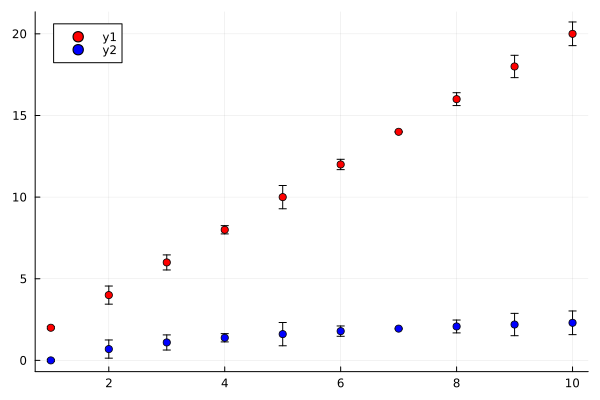

In [32]:
# Mozna odwolywac sie bezposrednio do kolumn w poniższy sposób (gdyz sa typu jednowymiarowych tablic 
# Array{T,1})
#Pkg.add("Plots")
using Plots
scatter(df.a, [df.b, df.c], colour = [:red :blue], yerr=df.d)


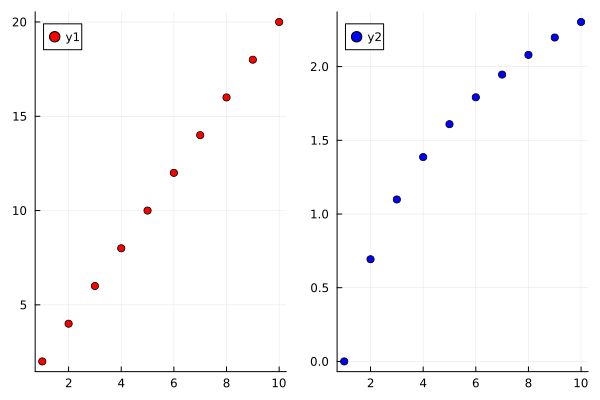

In [33]:
# użycie opcji layout
scatter(df.a, [df.b, df.c],  colour = [:red :blue ], layout=2)

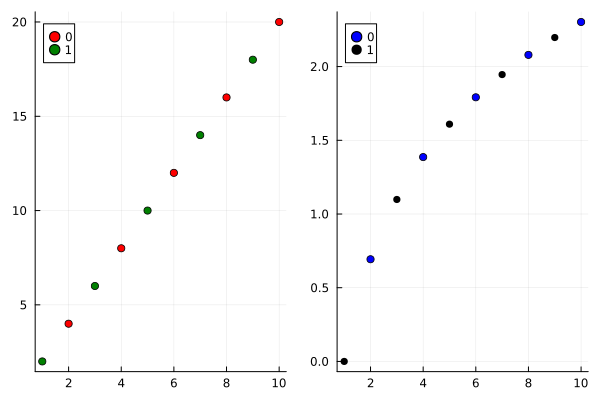

In [34]:
# użycie opcji layout i grup
scatter(df.a, [df.b, df.c], group=df.e,  colour = [:red :blue :green :black], layout=2)

Uwaga: Ze względu na specyfikę języka Julia pomiar czasu wykonania należy brać pod uwagę dopiero od drugiego wywołania danej funkcji
(za pierwszym razem mierzymy również czas kompilacji)

Makro @time - zwraca wartość funkcji i wypisuje czas jej trwania.
Makro @elapsed zwraca czas trwania (może być wygodniejsze w użyciu). 
Warto też oglądnąć działanie makr @timev, @timed, i @allocated

https://docs.julialang.org/en/v1/base/base/#Base.@time

Rand(10) - wylosuj 10-elementową tablicę Float64 z przedziału [0,1)

https://docs.julialang.org/en/v1/stdlib/Random/#Base.rand

### Zadanie 
- Założenie: macierz A - kwadratowa rozmiar n x n; wektory x, y rozmiar n
- Napisać programy w języku Julia do obliczania: <b>uogólnionego</b> iloczynu skalarnego dot(x, <b>A</b>, y) wektorów z użyciem <a href="https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#LinearAlgebra.dot-Tuple{Any,%20Any,%20Any}">LinearAlgebra.dot</a> oraz mnożenia macierzy kwadratowej przez wektor (czyli obliczania A*x) z użyciem 
<a href="https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/#Elementary-operations-1">operatora *</a>.
- Uruchomić i zmierzyć czasy działania obydwu funkcji - każdej dla różnych rozmiarów wektorów n. Uwaga: rozmiary dobrać tak, żeby nie zużyć zbyt wiele pamięci, a jednocześnie uzyskać niezerowe wyniki czasowe (wielkości będą zależeć od mocy sprzętu - można próbować testować w okolicach n=1000). Dokonać 10 pomiarów dla każdego rozmiaru wektora.
- Czasy działania powinny  być zapisywane do <b>jednego</b> pliku CSV. Należy zaplanować odpowiednią strukturę kolumn takiego pliku.
- Wczytać dane z w/w pliku do <b>jednego</b> DataFrame w języku Julia. 
- Korzystająć z mechanizmów DataFrame w języku Julia obliczyć średnią i odchylenie standardowe, w taki sposób, aby narysować wykresy średnich czasów obliczenia operacji w zależności od rozmiaru wektora. Dodać słupki błędów do obydwu wykresów uzyskanych z obliczenia odchylenia standardowego. 
- Proszę poukładac wykresy  w tabelkę za pomocą  opcji layouts: https://docs.juliaplots.org/latest/layouts/#Simple-Layouts-1.
- Należy zadbać o staranne podpisanie osi i wykresów.

In [35]:
# using Pkg
# Pkg.add("LinearAlgebra")
using LinearAlgebra

function dot_general_lib(x, A, y)
    dot(x, A, y)
end

function mul_matrix_vector(A, x)
    A * x
end

function generate_data(n)
    x = rand(1.0:5.0, n) # <- vector with rand values [1, 5] with len = n
    y = rand(1.0:5.0, n)
    A = rand(1.0:5.0, n, n) # <- same with matrix
    return x, y, A
end

generate_data (generic function with 1 method)

In [36]:
x, y, A = generate_data(5)

([4.0, 4.0, 3.0, 5.0, 1.0], [4.0, 3.0, 2.0, 2.0, 5.0], [4.0 1.0 … 4.0 2.0; 5.0 4.0 … 4.0 1.0; … ; 5.0 5.0 … 4.0 2.0; 3.0 1.0 … 5.0 5.0])

In [79]:
function run_benchmarks()
    sizes = [100, 200, 500, 600, 700, 800, 900, 1000, 1500, 2000, 2500, 3000, 3000, 3500, 4000, 4500, 5000]
    df1 = DataFrame(n = Int[], algorithm = String[], time = Float64[])
    
    x_w, y_w, A_w = generate_data(10)
    dot_general_lib(x_w, A_w, y_w)
    mul_matrix_vector(A_w, x_w)
    
    for n in sizes
        for i in 1:10
            x, y, A = generate_data(n)
            
            t1 = time()
            dot_general_lib(x, A, y)
            dt1 = time() - t1
            push!(df1, (n, "dot(x, A, y)", dt1))
            
            t2 = time()
            mul_matrix_vector(A, x)
            dt2 = time() - t2
            push!(df1, (n, "A * x", dt2))
        end
    end

    CSV.write("benchmarks.csv", df1)
end

run_benchmarks (generic function with 1 method)

In [80]:
run_benchmarks()

"benchmarks.csv"

In [81]:
df = CSV.read("benchmarks.csv", DataFrame)

Row,n,algorithm,time
,Int64,String15,Float64
1,100,"dot(x, A, y)",9.53674e-7
2,100,A * x,1.90735e-6
3,100,"dot(x, A, y)",1.19209e-6
4,100,A * x,5.96046e-6
5,100,"dot(x, A, y)",1.90735e-6
6,100,A * x,1.90735e-6
7,100,"dot(x, A, y)",9.53674e-7
8,100,A * x,9.53674e-7
9,100,"dot(x, A, y)",9.53674e-7


In [82]:
stats = combine(groupby(df, [:n, :algorithm]), 
    :time => mean => :time_mean, 
    :time => std  => :time_std
)

stats_dot = filter(row -> row.algorithm == "dot(x, A, y)", stats)
stats_mul = filter(row -> row.algorithm == "A * x", stats)

Row,n,algorithm,time_mean,time_std
,Int64,String15,Float64,Float64
1,100,A * x,1.88351e-6,1.51395e-6
2,200,A * x,1.25408e-5,1.27539e-5
3,500,A * x,8.76188e-5,6.08053e-5
4,600,A * x,7.79867e-5,2.20532e-5
5,700,A * x,0.000248337,9.4452e-5
6,800,A * x,0.000283623,7.26207e-5
7,900,A * x,0.000305939,8.96016e-5
8,1000,A * x,0.000450349,0.000213864
9,1500,A * x,0.000643015,9.95354e-5


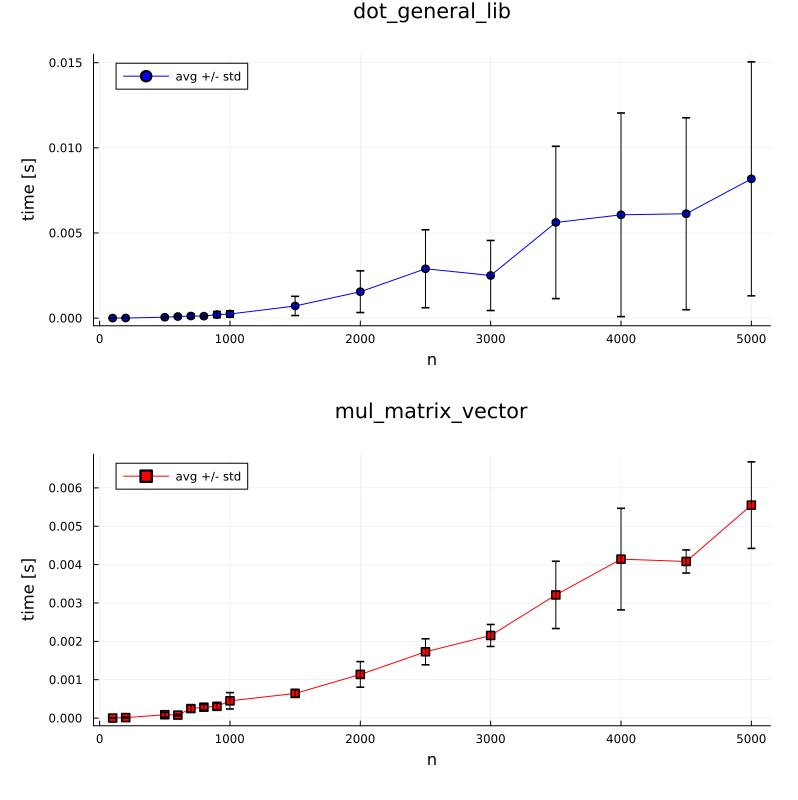

In [87]:
p1 = plot(stats_dot.n, stats_dot.time_mean, 
    yerror = stats_dot.time_std, 
    title = "dot_general_lib", 
    xlabel = "n", 
    ylabel = "time [s]", 
    label = "avg +/- std", 
    marker = :circle, 
    color = :blue
)

p2 = plot(stats_mul.n, stats_mul.time_mean, 
    yerror = stats_mul.time_std, 
    title = "mul_matrix_vector", 
    xlabel = "n", 
    ylabel = "time [s]", 
    label = "avg +/- std", 
    marker = :square, 
    color = :red
)

final = plot(p1, p2, layout = (2, 1), size = (800, 800), margin = 5Plots.mm)
display(final)